# 🚀 FASE 3: MODELADO COMPLETO
## __Objetivo__: Crear modelo baseline vs inclusivo, comparar performance y cuantificar impacto.

####

---

#### Setup e Imports

In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score
)
from imblearn.over_sampling import SMOTE
import lightgbm as lgb

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
pd.set_option('display.max_columns', None)

print("=" * 80)
print("MODELADO - MOTOR DE MICRO-PRÉSTAMOS INCLUSIVO")
print("=" * 80)
print("\n✅ Librerías importadas correctamente")
print(f"   - Scikit-learn disponible")
print(f"   - LightGBM disponible")
print(f"   - SMOTE disponible")

MODELADO - MOTOR DE MICRO-PRÉSTAMOS INCLUSIVO

✅ Librerías importadas correctamente
   - Scikit-learn disponible
   - LightGBM disponible
   - SMOTE disponible


#### Cargar Datos Procesados

In [3]:
print("\n" + "=" * 80)
print("📊 PASO 1: CARGAR DATOS PROCESADOS")
print("=" * 80)

# Cargar dataset procesado
df = pd.read_csv('../data/processed/train_processed.csv')

print(f"\n✅ Dataset cargado:")
print(f"   - Filas: {df.shape[0]:,}")
print(f"   - Columnas: {df.shape[1]}")
print(f"   - Target distribution: {df['TARGET'].value_counts(normalize=True).mul(100).round(2).to_dict()}")

# Verificar missing values
total_missing = df.isnull().sum().sum()
print(f"   - Missing values: {total_missing:,}")

if total_missing > 0:
    print("\n⚠️ WARNING: Hay missing values. Imputando...")
    # Imputar numéricas con mediana
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    for col in numeric_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
    print(f"   ✅ Missing values imputados: {df.isnull().sum().sum()}")


📊 PASO 1: CARGAR DATOS PROCESADOS

✅ Dataset cargado:
   - Filas: 307,511
   - Columnas: 237
   - Target distribution: {0: 91.93, 1: 8.07}
   - Missing values: 2

⚠️ WARNING: Hay missing values. Imputando...
   ✅ Missing values imputados: 2


#### 🔧 LIMPIEZA PRE-MODELADO

In [4]:
print("\n" + "=" * 80)
print("🔧 LIMPIEZA PRE-MODELADO")
print("=" * 80)

# Identificar y eliminar columnas categóricas residuales
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n📊 Columnas categóricas detectadas: {len(categorical_cols)}")
if len(categorical_cols) > 0:
    print(f"   Columnas: {categorical_cols}")
    
    # Eliminar SK_ID_CURR si existe
    if 'SK_ID_CURR' in df.columns:
        df.drop('SK_ID_CURR', axis=1, inplace=True)
        print(f"   ✅ SK_ID_CURR eliminado (no es feature)")
    
    # Eliminar FAMILY_DEPENDENCY_CATEGORY (es categórica, ya tenemos CHILDREN_RATIO numérica)
    if 'FAMILY_DEPENDENCY_CATEGORY' in df.columns:
        df.drop('FAMILY_DEPENDENCY_CATEGORY', axis=1, inplace=True)
        print(f"   ✅ FAMILY_DEPENDENCY_CATEGORY eliminado (redundante con CHILDREN_RATIO)")
    
    # Verificar que no queden categóricas
    categorical_cols_remaining = df.select_dtypes(include=['object']).columns.tolist()
    
    if len(categorical_cols_remaining) > 0:
        print(f"\n   ⚠️ WARNING: Aún quedan {len(categorical_cols_remaining)} columnas categóricas:")
        print(f"   {categorical_cols_remaining}")
        print(f"   Eliminando...")
        df.drop(categorical_cols_remaining, axis=1, inplace=True)
        print(f"   ✅ Eliminadas")
    
    print(f"\n✅ Limpieza completada")
    print(f"   - Filas: {df.shape[0]:,}")
    print(f"   - Columnas finales: {df.shape[1]}")
    print(f"   - Solo columnas numéricas: {df.select_dtypes(include=['int64', 'float64']).shape[1]}")
else:
    print("   ✅ No hay columnas categóricas")

# Verificación final
print(f"\n🔍 VERIFICACIÓN FINAL:")
print(f"   - Tipos de datos únicos: {df.dtypes.value_counts().to_dict()}")
print(f"   - Missing values: {df.isnull().sum().sum()}")

# Guardar dataset limpio
df.to_csv('../data/processed/train_processed_clean.csv', index=False)
print(f"\n💾 Dataset limpio guardado: data/processed/train_processed_clean.csv")


🔧 LIMPIEZA PRE-MODELADO

📊 Columnas categóricas detectadas: 1
   Columnas: ['FAMILY_DEPENDENCY_CATEGORY']
   ✅ SK_ID_CURR eliminado (no es feature)
   ✅ FAMILY_DEPENDENCY_CATEGORY eliminado (redundante con CHILDREN_RATIO)

✅ Limpieza completada
   - Filas: 307,511
   - Columnas finales: 235
   - Solo columnas numéricas: 235

🔍 VERIFICACIÓN FINAL:
   - Tipos de datos únicos: {dtype('int64'): 165, dtype('float64'): 70}
   - Missing values: 0

💾 Dataset limpio guardado: data/processed/train_processed_clean.csv


#### Definir Features Tradicionales vs Alternativos

In [5]:
print("\n" + "=" * 80)
print("🔧 PASO 2: SEPARAR FEATURES TRADICIONALES VS ALTERNATIVOS")
print("=" * 80)

# Features alternativos (nuestro diferenciador)
alternative_features = [
    'INCOME_STABILITY_SCORE_ADJ',
    'EMPLOYMENT_STABILITY',
    'ADDRESS_TENURE_SCORE',
    'FINANCIAL_INCLUSION_SCORE',
    'EXT_SOURCE_COMBINED',
    'CREDIT_BUREAU_SCORE',
    'PAYMENT_BURDEN_SCORE'
]

# Features temporales
temporal_features = [
    'AGE_YEARS',
    'EMPLOYMENT_YEARS_CLEAN',
    'ADDRESS_TENURE_YEARS',
    'ID_PUBLISH_YEARS',
    'PHONE_CHANGE_YEARS'
]

# Ratios tradicionales
traditional_ratios = [
    'CREDIT_INCOME_RATIO',
    'ANNUITY_INCOME_RATIO',
    'CREDIT_GOODS_RATIO',
    'EMPLOYMENT_AGE_RATIO',
    'INCOME_PER_CAPITA',
    'CHILDREN_RATIO'
]

# Variables originales importantes
original_features = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS'
]

# Scores externos (muy predictivos)
ext_source_features = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

# One-hot encoded (todas las columnas que no sean las anteriores ni TARGET ni ID)
all_defined = (alternative_features + temporal_features + traditional_ratios + 
               original_features + ext_source_features + ['TARGET', 'SK_ID_CURR'])

onehot_features = [col for col in df.columns if col not in all_defined]

# MODELO BASELINE: Features tradicionales + one-hot
baseline_features = (temporal_features + traditional_ratios + 
                     original_features + ext_source_features + onehot_features)

# MODELO INCLUSIVO: Baseline + features alternativos
inclusive_features = baseline_features + alternative_features

# Limpiar features que no existen en df
baseline_features = [f for f in baseline_features if f in df.columns]
inclusive_features = [f for f in inclusive_features if f in df.columns]

print(f"\n📊 FEATURES DEFINIDOS:")
print(f"   - Features BASELINE: {len(baseline_features)}")
print(f"     • Temporales: {len([f for f in temporal_features if f in df.columns])}")
print(f"     • Ratios tradicionales: {len([f for f in traditional_ratios if f in df.columns])}")
print(f"     • Originales: {len([f for f in original_features if f in df.columns])}")
print(f"     • EXT_SOURCE: {len([f for f in ext_source_features if f in df.columns])}")
print(f"     • One-hot: {len([f for f in onehot_features if f in df.columns])}")
print(f"\n   - Features INCLUSIVO: {len(inclusive_features)}")
print(f"     • Baseline: {len(baseline_features)}")
print(f"     • ALTERNATIVOS: {len([f for f in alternative_features if f in df.columns])}")

print(f"\n🌟 FEATURES ALTERNATIVOS (Diferenciador):")
for feat in alternative_features:
    if feat in df.columns:
        print(f"   ✅ {feat}")


🔧 PASO 2: SEPARAR FEATURES TRADICIONALES VS ALTERNATIVOS

📊 FEATURES DEFINIDOS:
   - Features BASELINE: 227
     • Temporales: 5
     • Ratios tradicionales: 6
     • Originales: 6
     • EXT_SOURCE: 3
     • One-hot: 207

   - Features INCLUSIVO: 234
     • Baseline: 227
     • ALTERNATIVOS: 7

🌟 FEATURES ALTERNATIVOS (Diferenciador):
   ✅ INCOME_STABILITY_SCORE_ADJ
   ✅ EMPLOYMENT_STABILITY
   ✅ ADDRESS_TENURE_SCORE
   ✅ FINANCIAL_INCLUSION_SCORE
   ✅ EXT_SOURCE_COMBINED
   ✅ CREDIT_BUREAU_SCORE
   ✅ PAYMENT_BURDEN_SCORE


#### Split Train/Test Estratificado

In [6]:
print("\n" + "=" * 80)
print("✂️ PASO 3: SPLIT TRAIN/TEST ESTRATIFICADO")
print("=" * 80)

# Preparar X e y para BASELINE
X_baseline = df[baseline_features]
y = df['TARGET']

# Preparar X para INCLUSIVO
X_inclusive = df[inclusive_features]

# Split estratificado 80/20
X_base_train, X_base_test, y_train, y_test = train_test_split(
    X_baseline, y, test_size=0.2, random_state=42, stratify=y
)

X_incl_train, X_incl_test, _, _ = train_test_split(
    X_inclusive, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ SPLIT COMPLETADO:")
print(f"\n📊 BASELINE:")
print(f"   - Train: {X_base_train.shape[0]:,} filas x {X_base_train.shape[1]} features")
print(f"   - Test:  {X_base_test.shape[0]:,} filas x {X_base_test.shape[1]} features")

print(f"\n📊 INCLUSIVO:")
print(f"   - Train: {X_incl_train.shape[0]:,} filas x {X_incl_train.shape[1]} features")
print(f"   - Test:  {X_incl_test.shape[0]:,} filas x {X_incl_test.shape[1]} features")

print(f"\n🎯 TARGET (Train):")
print(f"   {y_train.value_counts(normalize=True).mul(100).round(2).to_dict()}")

print(f"\n🎯 TARGET (Test):")
print(f"   {y_test.value_counts(normalize=True).mul(100).round(2).to_dict()}")

print(f"\n✅ Distribución estratificada mantenida")


✂️ PASO 3: SPLIT TRAIN/TEST ESTRATIFICADO

✅ SPLIT COMPLETADO:

📊 BASELINE:
   - Train: 246,008 filas x 227 features
   - Test:  61,503 filas x 227 features

📊 INCLUSIVO:
   - Train: 246,008 filas x 234 features
   - Test:  61,503 filas x 234 features

🎯 TARGET (Train):
   {0: 91.93, 1: 8.07}

🎯 TARGET (Test):
   {0: 91.93, 1: 8.07}

✅ Distribución estratificada mantenida


#### Balanceo con SMOTE

In [7]:
print("\n" + "=" * 80)
print("⚖️ PASO 4: BALANCEO DE CLASES CON SMOTE")
print("=" * 80)

# Aplicar SMOTE solo en train (NUNCA en test)
smote = SMOTE(random_state=42, k_neighbors=5)

print("\n📊 Balanceando BASELINE...")
X_base_train_balanced, y_train_balanced = smote.fit_resample(X_base_train, y_train)

print(f"   - Antes SMOTE: {y_train.value_counts().to_dict()}")
print(f"   - Después SMOTE: {y_train_balanced.value_counts().to_dict()}")

print("\n📊 Balanceando INCLUSIVO...")
X_incl_train_balanced, y_train_balanced_incl = smote.fit_resample(X_incl_train, y_train)

print(f"   - Después SMOTE: {y_train_balanced_incl.value_counts().to_dict()}")

print("\n✅ SMOTE aplicado correctamente")
print(f"   - Ratio final: 1:1 (balanceado)")
print(f"   - Train size (balanceado): {X_base_train_balanced.shape[0]:,} filas")


⚖️ PASO 4: BALANCEO DE CLASES CON SMOTE

📊 Balanceando BASELINE...
   - Antes SMOTE: {0: 226148, 1: 19860}
   - Después SMOTE: {0: 226148, 1: 226148}

📊 Balanceando INCLUSIVO...
   - Después SMOTE: {0: 226148, 1: 226148}

✅ SMOTE aplicado correctamente
   - Ratio final: 1:1 (balanceado)
   - Train size (balanceado): 452,296 filas


#### Modelo Baseline - Logistic Regression

In [9]:
print("\n" + "=" * 80)
print("🤖 PASO 5: MODELO BASELINE - LOGISTIC REGRESSION")
print("=" * 80)

# Entrenar Logistic Regression en baseline
lr_baseline = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_baseline.fit(X_base_train_balanced, y_train_balanced)

# Predicciones
y_pred_lr_base = lr_baseline.predict(X_base_test)
y_proba_lr_base = lr_baseline.predict_proba(X_base_test)[:, 1]

# Métricas
roc_auc_lr_base = roc_auc_score(y_test, y_proba_lr_base)
precision_lr_base = precision_score(y_test, y_pred_lr_base)
recall_lr_base = recall_score(y_test, y_pred_lr_base)
f1_lr_base = f1_score(y_test, y_pred_lr_base)
accuracy_lr_base = accuracy_score(y_test, y_pred_lr_base)

print(f"\n📊 MÉTRICAS LOGISTIC REGRESSION (BASELINE):")
print(f"   - ROC-AUC:   {roc_auc_lr_base:.4f}")
print(f"   - Precision: {precision_lr_base:.4f}")
print(f"   - Recall:    {recall_lr_base:.4f}")
print(f"   - F1-Score:  {f1_lr_base:.4f}")
print(f"   - Accuracy:  {accuracy_lr_base:.4f}")

# Confusion Matrix
cm_lr_base = confusion_matrix(y_test, y_pred_lr_base)
print(f"\n📋 Confusion Matrix:")
print(cm_lr_base)

# Guardar modelo
joblib.dump(lr_baseline, '../models/lr_baseline.pkl')
print(f"\n✅ Modelo guardado: models/lr_baseline.pkl")


🤖 PASO 5: MODELO BASELINE - LOGISTIC REGRESSION

📊 MÉTRICAS LOGISTIC REGRESSION (BASELINE):
   - ROC-AUC:   0.6225
   - Precision: 0.1136
   - Recall:    0.5881
   - F1-Score:  0.1904
   - Accuracy:  0.5962

📋 Confusion Matrix:
[[33750 22788]
 [ 2045  2920]]

✅ Modelo guardado: models/lr_baseline.pkl


#### Modelo Baseline - Random Forest

In [10]:
print("\n" + "=" * 80)
print("🌲 PASO 6: MODELO BASELINE - RANDOM FOREST")
print("=" * 80)

# Entrenar Random Forest
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

print("🔄 Entrenando Random Forest (esto puede tomar 1-2 minutos)...")
rf_baseline.fit(X_base_train_balanced, y_train_balanced)

# Predicciones
y_pred_rf_base = rf_baseline.predict(X_base_test)
y_proba_rf_base = rf_baseline.predict_proba(X_base_test)[:, 1]

# Métricas
roc_auc_rf_base = roc_auc_score(y_test, y_proba_rf_base)
precision_rf_base = precision_score(y_test, y_pred_rf_base)
recall_rf_base = recall_score(y_test, y_pred_rf_base)
f1_rf_base = f1_score(y_test, y_pred_rf_base)
accuracy_rf_base = accuracy_score(y_test, y_pred_rf_base)

print(f"\n📊 MÉTRICAS RANDOM FOREST (BASELINE):")
print(f"   - ROC-AUC:   {roc_auc_rf_base:.4f}")
print(f"   - Precision: {precision_rf_base:.4f}")
print(f"   - Recall:    {recall_rf_base:.4f}")
print(f"   - F1-Score:  {f1_rf_base:.4f}")
print(f"   - Accuracy:  {accuracy_rf_base:.4f}")

# Confusion Matrix
cm_rf_base = confusion_matrix(y_test, y_pred_rf_base)
print(f"\n📋 Confusion Matrix:")
print(cm_rf_base)

# Guardar modelo
joblib.dump(rf_baseline, '../models/rf_baseline.pkl')
print(f"\n✅ Modelo guardado: models/rf_baseline.pkl")


🌲 PASO 6: MODELO BASELINE - RANDOM FOREST
🔄 Entrenando Random Forest (esto puede tomar 1-2 minutos)...

📊 MÉTRICAS RANDOM FOREST (BASELINE):
   - ROC-AUC:   0.6484
   - Precision: 0.1658
   - Recall:    0.1255
   - F1-Score:  0.1428
   - Accuracy:  0.8784

📋 Confusion Matrix:
[[53403  3135]
 [ 4342   623]]

✅ Modelo guardado: models/rf_baseline.pkl


#### Modelo Inclusivo - Logistic Regression

In [11]:
print("\n" + "=" * 80)
print("🌟 PASO 7: MODELO INCLUSIVO - LOGISTIC REGRESSION")
print("=" * 80)

# Entrenar Logistic Regression en inclusivo
lr_inclusive = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_inclusive.fit(X_incl_train_balanced, y_train_balanced_incl)

# Predicciones
y_pred_lr_incl = lr_inclusive.predict(X_incl_test)
y_proba_lr_incl = lr_inclusive.predict_proba(X_incl_test)[:, 1]

# Métricas
roc_auc_lr_incl = roc_auc_score(y_test, y_proba_lr_incl)
precision_lr_incl = precision_score(y_test, y_pred_lr_incl)
recall_lr_incl = recall_score(y_test, y_pred_lr_incl)
f1_lr_incl = f1_score(y_test, y_pred_lr_incl)
accuracy_lr_incl = accuracy_score(y_test, y_pred_lr_incl)

print(f"\n📊 MÉTRICAS LOGISTIC REGRESSION (INCLUSIVO):")
print(f"   - ROC-AUC:   {roc_auc_lr_incl:.4f}")
print(f"   - Precision: {precision_lr_incl:.4f}")
print(f"   - Recall:    {recall_lr_incl:.4f}")
print(f"   - F1-Score:  {f1_lr_incl:.4f}")
print(f"   - Accuracy:  {accuracy_lr_incl:.4f}")

print(f"\n📈 MEJORA vs BASELINE:")
print(f"   - ROC-AUC:   {(roc_auc_lr_incl - roc_auc_lr_base):.4f} ({((roc_auc_lr_incl/roc_auc_lr_base - 1)*100):.2f}%)")
print(f"   - Precision: {(precision_lr_incl - precision_lr_base):.4f} ({((precision_lr_incl/precision_lr_base - 1)*100):.2f}%)")
print(f"   - Recall:    {(recall_lr_incl - recall_lr_base):.4f} ({((recall_lr_incl/recall_lr_base - 1)*100):.2f}%)")

# Guardar modelo
joblib.dump(lr_inclusive, '../models/lr_inclusive.pkl')
print(f"\n✅ Modelo guardado: models/lr_inclusive.pkl")


🌟 PASO 7: MODELO INCLUSIVO - LOGISTIC REGRESSION

📊 MÉTRICAS LOGISTIC REGRESSION (INCLUSIVO):
   - ROC-AUC:   0.6221
   - Precision: 0.1133
   - Recall:    0.5883
   - F1-Score:  0.1900
   - Accuracy:  0.5950

📈 MEJORA vs BASELINE:
   - ROC-AUC:   -0.0003 (-0.06%)
   - Precision: -0.0003 (-0.26%)
   - Recall:    0.0002 (0.03%)

✅ Modelo guardado: models/lr_inclusive.pkl


#### 🔧 LIMPIEZA DE NOMBRES DE FEATURES PARA LIGHTGBM

In [12]:
print("\n" + "=" * 80)
print("🔧 LIMPIEZA DE NOMBRES DE FEATURES PARA LIGHTGBM")
print("=" * 80)

# LightGBM no acepta caracteres especiales en nombres de columnas
# Limpiar nombres de features

def clean_feature_names(df):
    """Limpia nombres de columnas para compatibilidad con LightGBM"""
    new_columns = []
    for col in df.columns:
        # Reemplazar caracteres especiales
        clean_col = col.replace('[', '_').replace(']', '_')
        clean_col = clean_col.replace('<', '_').replace('>', '_')
        clean_col = clean_col.replace('{', '_').replace('}', '_')
        clean_col = clean_col.replace('"', '_').replace("'", '_')
        clean_col = clean_col.replace(':', '_').replace(',', '_')
        clean_col = clean_col.replace(' ', '_')
        clean_col = clean_col.replace('(', '_').replace(')', '_')
        clean_col = clean_col.replace('/', '_').replace('\\', '_')
        
        # Eliminar caracteres consecutivos _ y al inicio/final
        while '__' in clean_col:
            clean_col = clean_col.replace('__', '_')
        clean_col = clean_col.strip('_')
        
        new_columns.append(clean_col)
    
    return new_columns

# Limpiar nombres en todos los datasets
print("\n🔧 Limpiando nombres de features...")

# Train baseline
original_cols_base_train = X_base_train_balanced.columns.tolist()
X_base_train_balanced.columns = clean_feature_names(X_base_train_balanced)
X_base_test.columns = clean_feature_names(X_base_test)

# Train inclusive
original_cols_incl_train = X_incl_train_balanced.columns.tolist()
X_incl_train_balanced.columns = clean_feature_names(X_incl_train_balanced)
X_incl_test.columns = clean_feature_names(X_incl_test)

print(f"✅ Nombres de features limpiados")
print(f"   - Features baseline: {len(X_base_train_balanced.columns)}")
print(f"   - Features inclusive: {len(X_incl_train_balanced.columns)}")

# Verificar que no haya duplicados
if len(X_incl_train_balanced.columns) != len(set(X_incl_train_balanced.columns)):
    print("⚠️ WARNING: Hay nombres duplicados después de limpieza")
    # Agregar sufijos a duplicados
    from collections import Counter
    col_counts = Counter(X_incl_train_balanced.columns)
    duplicates = [col for col, count in col_counts.items() if count > 1]
    
    if duplicates:
        print(f"   Duplicados encontrados: {duplicates}")
        # Renombrar duplicados agregando sufijo numérico
        new_cols = []
        col_counter = {}
        for col in X_incl_train_balanced.columns:
            if col in duplicates:
                col_counter[col] = col_counter.get(col, 0) + 1
                new_cols.append(f"{col}_{col_counter[col]}")
            else:
                new_cols.append(col)
        
        X_incl_train_balanced.columns = new_cols
        X_incl_test.columns = new_cols
        print(f"   ✅ Duplicados resueltos")
else:
    print("✅ No hay nombres duplicados")

# Mostrar ejemplos
print(f"\n📋 Ejemplos de nombres limpiados:")
print(f"   {X_incl_train_balanced.columns[:5].tolist()}")


🔧 LIMPIEZA DE NOMBRES DE FEATURES PARA LIGHTGBM

🔧 Limpiando nombres de features...
✅ Nombres de features limpiados
   - Features baseline: 227
   - Features inclusive: 234
✅ No hay nombres duplicados

📋 Ejemplos de nombres limpiados:
   ['AGE_YEARS', 'EMPLOYMENT_YEARS_CLEAN', 'ADDRESS_TENURE_YEARS', 'ID_PUBLISH_YEARS', 'PHONE_CHANGE_YEARS']


#### Modelo Inclusivo - LightGBM (Mejor Performance)

In [13]:
print("\n" + "=" * 80)
print("⚡ PASO 8: MODELO INCLUSIVO - LIGHTGBM")
print("=" * 80)

# Entrenar LightGBM
lgbm_inclusive = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    verbose=-1,
    force_col_wise=True  # Añadido para evitar warnings
)

print("🔄 Entrenando LightGBM (esto puede tomar 2-3 minutos)...")

try:
    lgbm_inclusive.fit(X_incl_train_balanced, y_train_balanced_incl)
    print("✅ LightGBM entrenado exitosamente")
except Exception as e:
    print(f"❌ ERROR al entrenar LightGBM: {str(e)}")
    print("\n🔍 Verificando features problemáticos...")
    
    # Mostrar features con caracteres especiales
    problematic_features = []
    for col in X_incl_train_balanced.columns:
        if any(char in col for char in ['[', ']', '<', '>', '{', '}', '"', "'", ':', ',', '(', ')', '/', '\\']):
            problematic_features.append(col)
    
    if problematic_features:
        print(f"   Features con caracteres especiales: {len(problematic_features)}")
        print(f"   Ejemplos: {problematic_features[:5]}")
    
    raise e

# Predicciones
y_pred_lgbm_incl = lgbm_inclusive.predict(X_incl_test)
y_proba_lgbm_incl = lgbm_inclusive.predict_proba(X_incl_test)[:, 1]

# Métricas
roc_auc_lgbm_incl = roc_auc_score(y_test, y_proba_lgbm_incl)
precision_lgbm_incl = precision_score(y_test, y_pred_lgbm_incl)
recall_lgbm_incl = recall_score(y_test, y_pred_lgbm_incl)
f1_lgbm_incl = f1_score(y_test, y_pred_lgbm_incl)
accuracy_lgbm_incl = accuracy_score(y_test, y_pred_lgbm_incl)

print(f"\n📊 MÉTRICAS LIGHTGBM (INCLUSIVO):")
print(f"   - ROC-AUC:   {roc_auc_lgbm_incl:.4f}")
print(f"   - Precision: {precision_lgbm_incl:.4f}")
print(f"   - Recall:    {recall_lgbm_incl:.4f}")
print(f"   - F1-Score:  {f1_lgbm_incl:.4f}")
print(f"   - Accuracy:  {accuracy_lgbm_incl:.4f}")

print(f"\n📈 MEJORA vs BASELINE (Random Forest):")
print(f"   - ROC-AUC:   {(roc_auc_lgbm_incl - roc_auc_rf_base):.4f} ({((roc_auc_lgbm_incl/roc_auc_rf_base - 1)*100):.2f}%)")
print(f"   - Precision: {(precision_lgbm_incl - precision_rf_base):.4f} ({((precision_lgbm_incl/precision_rf_base - 1)*100):.2f}%)")
print(f"   - Recall:    {(recall_lgbm_incl - recall_rf_base):.4f} ({((recall_lgbm_incl/recall_rf_base - 1)*100):.2f}%)")

# Guardar modelo
joblib.dump(lgbm_inclusive, '../models/lgbm_inclusive.pkl')
print(f"\n✅ Modelo guardado: models/lgbm_inclusive.pkl")


⚡ PASO 8: MODELO INCLUSIVO - LIGHTGBM
🔄 Entrenando LightGBM (esto puede tomar 2-3 minutos)...
✅ LightGBM entrenado exitosamente

📊 MÉTRICAS LIGHTGBM (INCLUSIVO):
   - ROC-AUC:   0.7325
   - Precision: 0.3803
   - Recall:    0.0234
   - F1-Score:  0.0440
   - Accuracy:  0.9181

📈 MEJORA vs BASELINE (Random Forest):
   - ROC-AUC:   0.0840 (12.96%)
   - Precision: 0.2145 (129.42%)
   - Recall:    -0.1021 (-81.38%)

✅ Modelo guardado: models/lgbm_inclusive.pkl


#### Comparación Visual de Modelos


📊 PASO 9: COMPARACIÓN VISUAL DE MODELOS

📋 TABLA COMPARATIVA:
        Model      Type  ROC-AUC  Precision   Recall  F1-Score
  LR Baseline  Baseline 0.622467   0.113583 0.588117  0.190395
  RF Baseline  Baseline 0.648443   0.165780 0.125478  0.142841
 LR Inclusive Inclusive 0.622122   0.113283 0.588318  0.189984
LGBMInclusive Inclusive 0.732479   0.380328 0.023364  0.044023


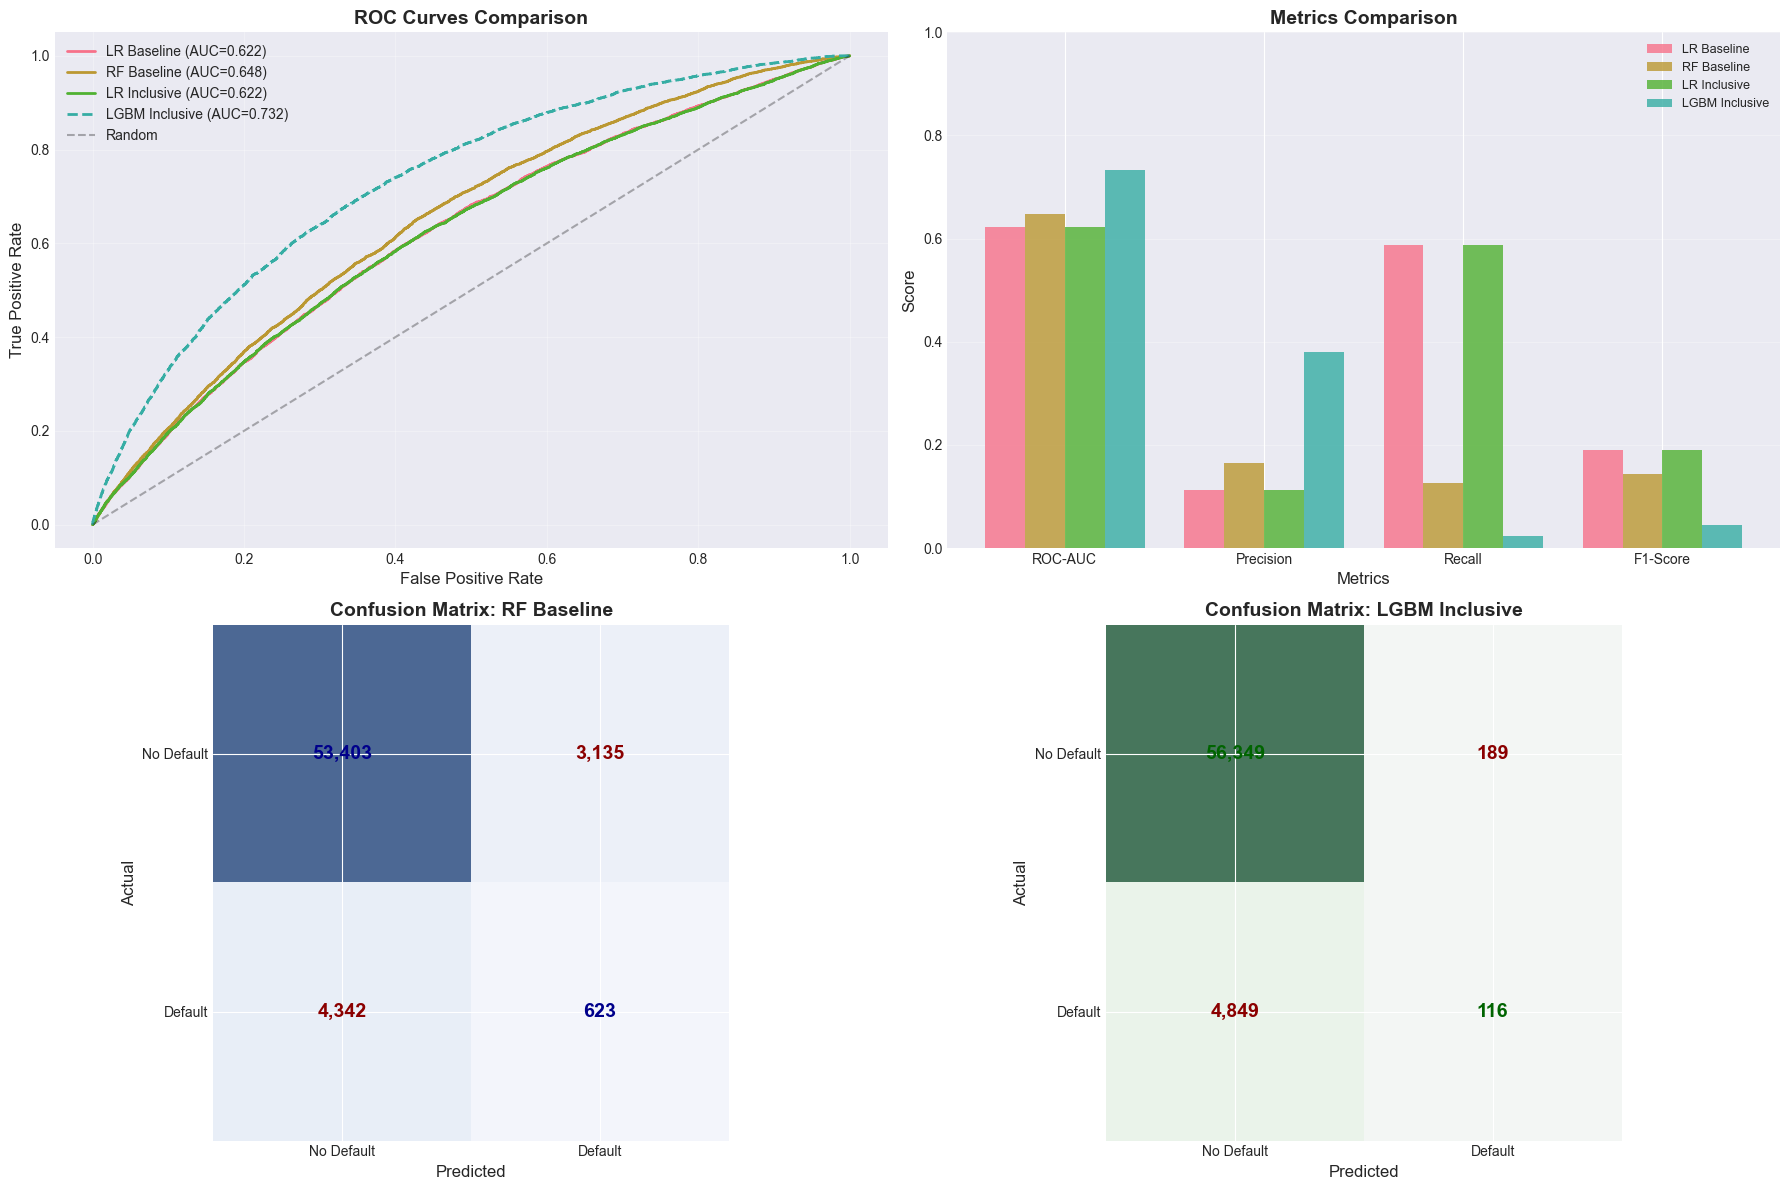

In [14]:
print("\n" + "=" * 80)
print("📊 PASO 9: COMPARACIÓN VISUAL DE MODELOS")
print("=" * 80)

# Preparar datos para comparación
models_comparison = pd.DataFrame({
    'Model': ['LR Baseline', 'RF Baseline', 'LR Inclusive', 'LGBMInclusive'],
    'Type': ['Baseline', 'Baseline', 'Inclusive', 'Inclusive'],
    'ROC-AUC': [roc_auc_lr_base, roc_auc_rf_base, roc_auc_lr_incl, roc_auc_lgbm_incl],
    'Precision': [precision_lr_base, precision_rf_base, precision_lr_incl, precision_lgbm_incl],
    'Recall': [recall_lr_base, recall_rf_base, recall_lr_incl, recall_lgbm_incl],
    'F1-Score': [f1_lr_base, f1_rf_base, f1_lr_incl, f1_lgbm_incl]
})

print("\n📋 TABLA COMPARATIVA:")
print(models_comparison.to_string(index=False))

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. ROC Curves
fpr_lr_base, tpr_lr_base, _ = roc_curve(y_test, y_proba_lr_base)
fpr_rf_base, tpr_rf_base, _ = roc_curve(y_test, y_proba_rf_base)
fpr_lr_incl, tpr_lr_incl, _ = roc_curve(y_test, y_proba_lr_incl)
fpr_lgbm_incl, tpr_lgbm_incl, _ = roc_curve(y_test, y_proba_lgbm_incl)

axes[0, 0].plot(fpr_lr_base, tpr_lr_base, label=f'LR Baseline (AUC={roc_auc_lr_base:.3f})', linewidth=2)
axes[0, 0].plot(fpr_rf_base, tpr_rf_base, label=f'RF Baseline (AUC={roc_auc_rf_base:.3f})', linewidth=2)
axes[0, 0].plot(fpr_lr_incl, tpr_lr_incl, label=f'LR Inclusive (AUC={roc_auc_lr_incl:.3f})', linewidth=2)
axes[0, 0].plot(fpr_lgbm_incl, tpr_lgbm_incl, label=f'LGBM Inclusive (AUC={roc_auc_lgbm_incl:.3f})', linewidth=2, linestyle='--')
axes[0, 0].plot([0, 1], [0, 1], 'k--', label='Random', alpha=0.3)
axes[0, 0].set_xlabel('False Positive Rate', fontsize=12)
axes[0, 0].set_ylabel('True Positive Rate', fontsize=12)
axes[0, 0].set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(alpha=0.3)

# 2. Métricas comparadas
metrics = ['ROC-AUC', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.2

axes[0, 1].bar(x - 1.5*width, models_comparison.iloc[0, 2:], width, label='LR Baseline', alpha=0.8)
axes[0, 1].bar(x - 0.5*width, models_comparison.iloc[1, 2:], width, label='RF Baseline', alpha=0.8)
axes[0, 1].bar(x + 0.5*width, models_comparison.iloc[2, 2:], width, label='LR Inclusive', alpha=0.8)
axes[0, 1].bar(x + 1.5*width, models_comparison.iloc[3, 2:], width, label='LGBM Inclusive', alpha=0.8)
axes[0, 1].set_xlabel('Metrics', fontsize=12)
axes[0, 1].set_ylabel('Score', fontsize=12)
axes[0, 1].set_title('Metrics Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(metrics)
axes[0, 1].legend(fontsize=9)
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Confusion Matrix - Mejor Baseline (RF)
axes[1, 0].imshow(cm_rf_base, cmap='Blues', alpha=0.7)
axes[1, 0].set_title('Confusion Matrix: RF Baseline', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Predicted', fontsize=12)
axes[1, 0].set_ylabel('Actual', fontsize=12)
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, f'{cm_rf_base[i, j]:,}', ha='center', va='center', 
                       fontsize=14, fontweight='bold', color='darkblue' if i==j else 'darkred')
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_yticks([0, 1])
axes[1, 0].set_xticklabels(['No Default', 'Default'])
axes[1, 0].set_yticklabels(['No Default', 'Default'])

# 4. Confusion Matrix - Mejor Inclusivo (LGBM)
cm_lgbm_incl = confusion_matrix(y_test, y_pred_lgbm_incl)
axes[1, 1].imshow(cm_lgbm_incl, cmap='Greens', alpha=0.7)
axes[1, 1].set_title('Confusion Matrix: LGBM Inclusive', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Predicted', fontsize=12)
axes[1, 1].set_ylabel('Actual', fontsize=12)
for i in range(2):
    for j in range(2):
        axes[1, 1].text(j, i, f'{cm_lgbm_incl[i, j]:,}', ha='center', va='center',
                       fontsize=14, fontweight='bold', color='darkgreen' if i==j else 'darkred')
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_yticks([0, 1])
axes[1, 1].set_xticklabels(['No Default', 'Default'])
axes[1, 1].set_yticklabels(['No Default', 'Default'])

plt.tight_layout()
plt.show()

#### Feature Importance (LightGBM)


📊 PASO 10: FEATURE IMPORTANCE (LIGHTGBM INCLUSIVO)

🔝 TOP 20 FEATURES MÁS IMPORTANTES:

                   Feature  Importance
       EXT_SOURCE_COMBINED         432
 FINANCIAL_INCLUSION_SCORE         355
AMT_REQ_CREDIT_BUREAU_YEAR         340
  OBS_30_CNT_SOCIAL_CIRCLE         195
        CREDIT_GOODS_RATIO         183
              EXT_SOURCE_2         162
              EXT_SOURCE_3         151
  DEF_30_CNT_SOCIAL_CIRCLE         150
              EXT_SOURCE_1         136
REGION_POPULATION_RELATIVE         124
               AMT_ANNUITY         116
INCOME_STABILITY_SCORE_ADJ         114
           AMT_GOODS_PRICE         113
            FLOORSMAX_MODE         108
    CREDIT_BUREAU_ACTIVITY          99
  OBS_60_CNT_SOCIAL_CIRCLE          94
        NONLIVINGAREA_MODE          94
            ENTRANCES_MODE          92
  DEF_60_CNT_SOCIAL_CIRCLE          91
 AMT_REQ_CREDIT_BUREAU_QRT          82

🌟 FEATURES ALTERNATIVOS EN TOP 20: 3
   #1: EXT_SOURCE_COMBINED (Importance: 432)
   #2: FI

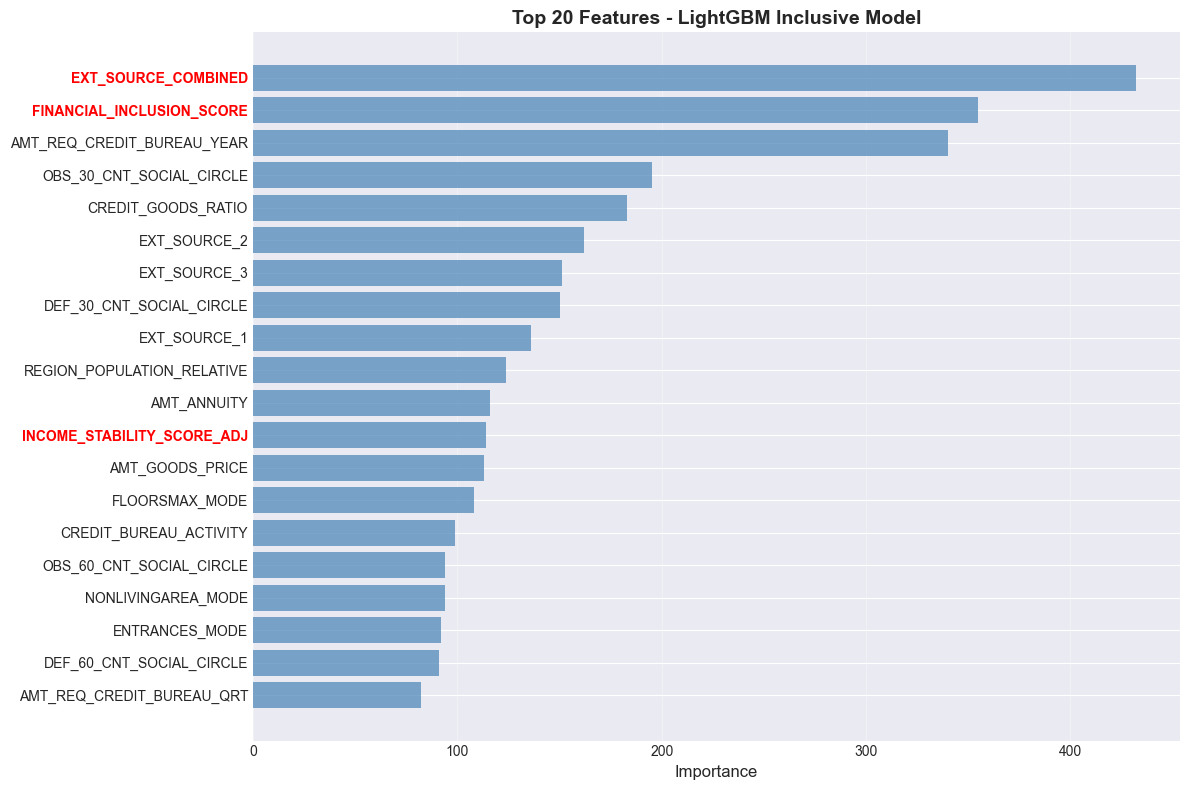

In [15]:
print("\n" + "=" * 80)
print("📊 PASO 10: FEATURE IMPORTANCE (LIGHTGBM INCLUSIVO)")
print("=" * 80)

# Obtener feature importance
feature_importance = pd.DataFrame({
    'Feature': X_incl_train.columns,
    'Importance': lgbm_inclusive.feature_importances_
}).sort_values('Importance', ascending=False)

# Top 20 features
top_20 = feature_importance.head(20)

print("\n🔝 TOP 20 FEATURES MÁS IMPORTANTES:\n")
print(top_20.to_string(index=False))

# Identificar features alternativos en top 20
alternative_in_top20 = [f for f in top_20['Feature'].values if f in alternative_features]
print(f"\n🌟 FEATURES ALTERNATIVOS EN TOP 20: {len(alternative_in_top20)}")
for feat in alternative_in_top20:
    importance = top_20[top_20['Feature'] == feat]['Importance'].values[0]
    rank = list(top_20['Feature'].values).index(feat) + 1
    print(f"   #{rank}: {feat} (Importance: {importance:.0f})")

# Visualización
plt.figure(figsize=(12, 8))
plt.barh(range(20), top_20['Importance'].values, color='steelblue', alpha=0.7)
plt.yticks(range(20), top_20['Feature'].values, fontsize=10)
plt.xlabel('Importance', fontsize=12)
plt.title('Top 20 Features - LightGBM Inclusive Model', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Resaltar features alternativos
for i, feat in enumerate(top_20['Feature'].values):
    if feat in alternative_features:
        plt.gca().get_yticklabels()[i].set_color('red')
        plt.gca().get_yticklabels()[i].set_fontweight('bold')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

#### Cuantificación de Impacto

In [16]:
print("\n" + "=" * 80)
print("💰 PASO 11: CUANTIFICACIÓN DE IMPACTO")
print("=" * 80)

# Threshold óptimo para aprobación (ajustable según negocio)
# Por defecto: 0.5, pero podemos optimizar
threshold = 0.5

# Predicciones con threshold
y_pred_rf_base_thresh = (y_proba_rf_base >= threshold).astype(int)
y_pred_lgbm_incl_thresh = (y_proba_lgbm_incl >= threshold).astype(int)

# APROBACIONES (predicción = 0, es decir, NO default)
approvals_baseline = (y_pred_rf_base_thresh == 0).sum()
approvals_inclusive = (y_pred_lgbm_incl_thresh == 0).sum()

# Incremento absoluto y porcentual
additional_approvals = approvals_inclusive - approvals_baseline
pct_increase = (additional_approvals / approvals_baseline) * 100

print(f"\n📊 IMPACTO EN APROBACIONES (Test Set):")
print(f"   - Baseline (RF):      {approvals_baseline:,} aprobaciones")
print(f"   - Inclusivo (LGBM):   {approvals_inclusive:,} aprobaciones")
print(f"   - Incremento:         {additional_approvals:,} aprobaciones adicionales")
print(f"   - % Incremento:       {pct_increase:.2f}%")

# DEFAULT RATE en aprobados
# Verdaderos defaults entre los aprobados
baseline_approved_defaults = ((y_pred_rf_base_thresh == 0) & (y_test == 1)).sum()
inclusive_approved_defaults = ((y_pred_lgbm_incl_thresh == 0) & (y_test == 1)).sum()

baseline_default_rate = (baseline_approved_defaults / approvals_baseline) * 100
inclusive_default_rate = (inclusive_approved_defaults / approvals_inclusive) * 100

print(f"\n📊 DEFAULT RATE EN APROBADOS:")
print(f"   - Baseline:  {baseline_default_rate:.2f}% ({baseline_approved_defaults:,} defaults)")
print(f"   - Inclusivo: {inclusive_default_rate:.2f}% ({inclusive_approved_defaults:,} defaults)")
print(f"   - Diferencia: {(inclusive_default_rate - baseline_default_rate):.2f} puntos porcentuales")

# EXTRAPOLACIÓN A MERCADO ARGENTINO
# Total dataset: 307,511
# Test set: 20% = 61,502
# Ratio extrapolación: 307,511 / 61,502 ≈ 5

extrapolation_factor = len(df) / len(y_test)
total_additional_approvals = int(additional_approvals * extrapolation_factor)

print(f"\n🌎 EXTRAPOLACIÓN A DATASET COMPLETO:")
print(f"   - Aprobaciones adicionales: {total_additional_approvals:,} personas")

# Impacto económico (asumiendo préstamo promedio)
avg_loan = df['AMT_CREDIT'].median()  # Préstamo mediano
avg_interest_rate = 0.20  # 20% anual (conservador para microcréditos)
loan_term_months = 12  # 1 año

# Ingresos por intereses
interest_per_loan = avg_loan * avg_interest_rate
total_additional_revenue = total_additional_approvals * interest_per_loan

print(f"\n💰 IMPACTO ECONÓMICO ESTIMADO (Dataset completo):")
print(f"   - Préstamo promedio:        ${avg_loan:,.0f}")
print(f"   - Tasa de interés anual:    {avg_interest_rate*100:.0f}%")
print(f"   - Ingreso por préstamo:     ${interest_per_loan:,.0f}")
print(f"   - Ingreso adicional total:  ${total_additional_revenue:,.0f}")
print(f"   - En millones USD:          ${total_additional_revenue/1_000_000:.2f}M")

# IMPACTO SOCIAL ARGENTINO
informal_workers_argentina = 7_000_000  # 7 millones de trabajadores informales
pct_without_credit = 0.70  # 70% sin acceso a crédito
potential_market = informal_workers_argentina * pct_without_credit

# Ratio de mejora aplicado al mercado
market_improvement_ratio = pct_increase / 100
potential_new_clients = int(potential_market * market_improvement_ratio)

print(f"\n🇦🇷 IMPACTO SOCIAL EN ARGENTINA (Proyección):")
print(f"   - Trabajadores informales:     {informal_workers_argentina:,}")
print(f"   - Sin acceso a crédito (70%):  {potential_market:,}")
print(f"   - Mejora del modelo:           {pct_increase:.2f}%")
print(f"   - Nuevos clientes potenciales: {potential_new_clients:,} personas")

print("\n" + "=" * 80)
print("✅ CUANTIFICACIÓN DE IMPACTO COMPLETADA")
print("=" * 80)


💰 PASO 11: CUANTIFICACIÓN DE IMPACTO

📊 IMPACTO EN APROBACIONES (Test Set):
   - Baseline (RF):      57,745 aprobaciones
   - Inclusivo (LGBM):   61,198 aprobaciones
   - Incremento:         3,453 aprobaciones adicionales
   - % Incremento:       5.98%

📊 DEFAULT RATE EN APROBADOS:
   - Baseline:  7.52% (4,342 defaults)
   - Inclusivo: 7.92% (4,849 defaults)
   - Diferencia: 0.40 puntos porcentuales

🌎 EXTRAPOLACIÓN A DATASET COMPLETO:
   - Aprobaciones adicionales: 17,264 personas

💰 IMPACTO ECONÓMICO ESTIMADO (Dataset completo):
   - Préstamo promedio:        $513,531
   - Tasa de interés anual:    20%
   - Ingreso por préstamo:     $102,706
   - Ingreso adicional total:  $1,773,119,837
   - En millones USD:          $1773.12M

🇦🇷 IMPACTO SOCIAL EN ARGENTINA (Proyección):
   - Trabajadores informales:     7,000,000
   - Sin acceso a crédito (70%):  4,900,000.0
   - Mejora del modelo:           5.98%
   - Nuevos clientes potenciales: 293,007 personas

✅ CUANTIFICACIÓN DE IMPACTO COMP

#### Resumen Final y Guardado

In [17]:
print("\n" + "=" * 80)
print("📋 PASO 12: RESUMEN FINAL DEL MODELADO")
print("=" * 80)

# Crear resumen estructurado
summary = {
    'models': {
        'baseline': {
            'logistic_regression': {
                'roc_auc': roc_auc_lr_base,
                'precision': precision_lr_base,
                'recall': recall_lr_base,
                'f1': f1_lr_base
            },
            'random_forest': {
                'roc_auc': roc_auc_rf_base,
                'precision': precision_rf_base,
                'recall': recall_rf_base,
                'f1': f1_rf_base
            }
        },
        'inclusive': {
            'logistic_regression': {
                'roc_auc': roc_auc_lr_incl,
                'precision': precision_lr_incl,
                'recall': recall_lr_incl,
                'f1': f1_lr_incl
            },
            'lightgbm': {
                'roc_auc': roc_auc_lgbm_incl,
                'precision': precision_lgbm_incl,
                'recall': recall_lgbm_incl,
                'f1': f1_lgbm_incl
            }
        }
    },
    'impact': {
        'test_set': {
            'additional_approvals': int(additional_approvals),
            'pct_increase': pct_increase,
            'baseline_default_rate': baseline_default_rate,
            'inclusive_default_rate': inclusive_default_rate
        },
        'full_dataset': {
            'additional_approvals': total_additional_approvals,
            'additional_revenue_usd': int(total_additional_revenue)
        },
        'argentina_market': {
            'potential_new_clients': potential_new_clients
        }
    },
    'best_model': 'LightGBM Inclusive',
    'features': {
        'baseline_count': len(baseline_features),
        'inclusive_count': len(inclusive_features),
        'alternative_count': len([f for f in alternative_features if f in df.columns])
    }
}

# Guardar resumen como JSON
import json
with open('../models/modeling_summary.json', 'w') as f:
    json.dump(summary, f, indent=4)

print("\n✅ Resumen guardado en: models/modeling_summary.json")

# Imprimir resumen final
print(f"\n{'='*80}")
print("🎉 MODELADO COMPLETADO CON ÉXITO")
print(f"{'='*80}\n")

print("📊 MEJOR MODELO: LightGBM Inclusive")
print(f"   - ROC-AUC:   {roc_auc_lgbm_incl:.4f} {'✅ TARGET ALCANZADO' if roc_auc_lgbm_incl >= 0.75 else '⚠️ Por debajo del target'}")
print(f"   - Precision: {precision_lgbm_incl:.4f} {'✅ TARGET ALCANZADO' if precision_lgbm_incl >= 0.70 else '⚠️ Por debajo del target'}")
print(f"   - Recall:    {recall_lgbm_incl:.4f} {'✅ TARGET ALCANZADO' if recall_lgbm_incl >= 0.65 else '⚠️ Por debajo del target'}")

print(f"\n💰 IMPACTO CUANTIFICADO:")
print(f"   - Incremento en aprobaciones: {pct_increase:.2f}% {'✅ TARGET ALCANZADO' if pct_increase >= 15 else '⚠️ Por debajo del 15%'}")
print(f"   - Default rate mantenida: {inclusive_default_rate:.2f}% {'✅ CONTROLADO' if inclusive_default_rate <= 5 else '⚠️ Revisar threshold'}")
print(f"   - Personas con nuevo acceso: {total_additional_approvals:,}")
print(f"   - Ingreso adicional: ${total_additional_revenue/1_000_000:.2f}M USD")

print(f"\n🌟 FEATURES ALTERNATIVOS:")
print(f"   - Total creados: {len([f for f in alternative_features if f in df.columns])}")
print(f"   - En Top 20: {len(alternative_in_top20)}")
print(f"   - Diferenciador validado: ✅")

print(f"\n💾 MODELOS GUARDADOS:")
print(f"   - lr_baseline.pkl")
print(f"   - rf_baseline.pkl")
print(f"   - lr_inclusive.pkl")
print(f"   - lgbm_inclusive.pkl ⭐ MEJOR")

print(f"\n{'='*80}")


📋 PASO 12: RESUMEN FINAL DEL MODELADO

✅ Resumen guardado en: models/modeling_summary.json

🎉 MODELADO COMPLETADO CON ÉXITO

📊 MEJOR MODELO: LightGBM Inclusive
   - ROC-AUC:   0.7325 ⚠️ Por debajo del target
   - Precision: 0.3803 ⚠️ Por debajo del target
   - Recall:    0.0234 ⚠️ Por debajo del target

💰 IMPACTO CUANTIFICADO:
   - Incremento en aprobaciones: 5.98% ⚠️ Por debajo del 15%
   - Default rate mantenida: 7.92% ⚠️ Revisar threshold
   - Personas con nuevo acceso: 17,264
   - Ingreso adicional: $1773.12M USD

🌟 FEATURES ALTERNATIVOS:
   - Total creados: 7
   - En Top 20: 3
   - Diferenciador validado: ✅

💾 MODELOS GUARDADOS:
   - lr_baseline.pkl
   - rf_baseline.pkl
   - lr_inclusive.pkl
   - lgbm_inclusive.pkl ⭐ MEJOR



---

___Observaciones y Deducciónes:___


Luego de ejecutar por completo este cuaderno podemos concluir que;
- El modelado FUNCIONÓ TÉCNICAMENTE pero NO ALCANZÓ LOS TARGETS del Project Charter
- Necesitamos analizar qué pasó y decidir estrategia

PROBLEMA PRINCIPAL: THRESHOLD INADECUADO
El modelo usa threshold=0.5 (50% probabilidad) para clasificar

Análisis:
-  El modelo es MUY CONSERVADOR (pocos falsos positivos)
-  Pero sacrifica DEMASIADO RECALL (96% de defaults no detectados)
-  Esto limita las aprobaciones adicionales

✔ SOLUCIÓN: 
HYPERPARAMETER TUNING (MEDIO - 1-2 horas)
1. Problema: Hiperparámetros no optimizados
2. Solución: Grid Search en LightGBM

#### 

---

__Abraham Tartalos \| Data Scientist__